# **BIDIRECTIONAL LSTM**

In [4]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" # "0" o "1"

In [5]:
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.set_visible_devices(gpus[0], 'GPU')
        tf.config.experimental.set_memory_growth(gpus[0], True)
        print("Using GPU:", gpus[0])
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found, using CPU.")


Using GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [10]:
from utils.utils_data_preprocessing import *
from utils.utils import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from gensim.models import KeyedVectors

import optuna
from functools import partial
from sklearn.utils import shuffle

ImportError: attempted relative import with no known parent package

In [ ]:
# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [ ]:
def prepare_data(datasets, max_words=20000, max_len=300):
    """
    Tokenization and label encoding for multiple datasets.

    Args:
        datasets (dict): A dictionary where keys are dataset names and values are pandas DataFrames with 'texts' and 'labels' columns.
        max_words (int): Maximum number of words to keep in the tokenizer vocabulary.
        max_len (int): Maximum length of sequences after padding/truncating.

    Returns:
        processed_datasets (dict): A dictionary with the same keys as input, where each value is another dict with 'train', 'val', 'test' splits containing (X, y) tuples.
        tokenizer (Tokenizer): Fitted Keras Tokenizer.
        encoder (LabelEncoder): Fitted sklearn LabelEncoder.
    """
    # Unisci tutti i testi di tutti i dataset
    all_texts = []
    for df in datasets.values():
        all_texts.extend(df["texts"].astype(str).tolist())

    # Tokenizer
    tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>") # tokenizer with OOV token
    tokenizer.fit_on_texts(all_texts) # create vocabulary {word: index}

    # LabelEncoder globale
    all_labels = np.concatenate([df["labels"].values for df in datasets.values()])
    encoder = LabelEncoder().fit(all_labels)

    # Applica tokenizzazione e encoding a ogni dataset
    processed_datasets = {}
    for name, df in datasets.items():
        seq = tokenizer.texts_to_sequences(df["texts"].astype(str).tolist()) # convert texts to sequences of integers
        X = pad_sequences(seq, maxlen=max_len, padding='post', truncating='post') # padd/truncate sequences to max_len
        y = encoder.transform(df["labels"].values) # encode labels to integers

        # Split train/val/test
        X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
        X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

        processed_datasets[name] = {
            "train": (X_train, y_train),
            "val": (X_val, y_val),
            "test": (X_test, y_test)
        }

    return processed_datasets, tokenizer, encoder

In [ ]:
def load_word2vec(tokenizer, max_words=20000, embedding_dim=300):
    """
    Load pre-trained Word2Vec embeddings and create embedding matrix

    Args:
        tokenizer: Keras Tokenizer object with fitted vocabulary
        max_words: maximum number of words to consider from tokenizer
        embedding_dim: dimension of Word2Vec embeddings

    Returns:
        embedding_matrix: numpy array of shape (num_words, embedding_dim)
        num_words: actual number of words considered
    """
    
    print("\nLoading pre-trained Word2Vec model (may take time)...")
    w2v_path = "../Word2Vec_GoogleNews300/word2vec-google-news-300.model"
    w2v_model = KeyedVectors.load(w2v_path, mmap='r') # load model with memory mapping (mmap='r' for only reading) 

    word_index = tokenizer.word_index               # vocabulary from tokenizer {word: index}
    num_words = min(max_words, len(word_index) + 1) # number of words to consider (max_words or vocab size)

    # create embedding matrix: each row corresponds to a word index from tokenizer, each column to an embedding dimension
    embedding_matrix = np.zeros((num_words, embedding_dim))
    for word, i in word_index.items():
        if i >= max_words: # skip because we only consider top max_words
            continue
        if word in w2v_model: # if word has a pre-trained embedding
            embedding_matrix[i] = w2v_model[word]

    return embedding_matrix, num_words

In [ ]:
# -----------------------
# Model building function
# -----------------------

def build_model(embedding_matrix, num_words, embedding_dim=300,
                num_units=96, dropout=0.4,
                hidden_units=32, learning_rate=1e-4):
    """
    Build and compile the CNN model.

    Args:
        embedding_matrix: Pre-trained embedding matrix
        num_words: Number of words in the vocabulary
        embedding_dim: Dimension of word embeddings
        num_units: Number of LSTM units
        dropout: Dropout rate
        hidden_units: Number of units in the dense hidden layer
        learning_rate: Learning rate for the Adam optimizer

    Returns:
        model: Compiled Keras BiLSTM model
    """

    model = Sequential([
        Embedding(
            num_words,
            embedding_dim,
            weights=[embedding_matrix],
            trainable=True),
        Bidirectional(LSTM(num_units, return_sequences=False, dropout=dropout, recurrent_dropout=0.0)),
        Dense(hidden_units, activation='relu'),
        Dropout(dropout),
        Dense(1, activation='sigmoid')
    ])

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
    
    return model

In [7]:
# -------------------------
# Optuna objective function
# -------------------------

def objectiveBiLSTM(trial, X_train, y_train, X_val, y_val, embedding_matrix, num_words, max_len=300, embedding_dim=300):
    """
    Optuna objective function for hyperparameter optimization of BiLSTM model.

    Args:
        trial: Optuna trial object
        X_train: Training data features
        y_train: Training data labels
        X_val: Validation data features
        y_val: Validation data labels

    Returns:
        f1: Weighted F1-score on validation data
    """

    num_units = trial.suggest_categorical("num_units", [16, 32, 64, 96, 128])            # number of LSTM units
    dropout = trial.suggest_categorical("dropout", [0.2, 0.4, 0.6, 0.8])                 # dropout rate
    hidden_units = trial.suggest_categorical("hidden_units", [8, 16, 32, 64])            # number of units in dense layer
    learning_rate = trial.suggest_categorical("learning_rate", [1e-5, 1e-4, 1e-3, 1e-2]) # learning rate for Adam optimizer

    model = build_model(
        embedding_matrix=embedding_matrix,
        num_words=num_words,
        embedding_dim=embedding_dim,
        num_units=num_units,
        dropout=dropout,
        hidden_units=hidden_units,
        learning_rate=learning_rate
    )

    # train model with early stopping
    es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=0)
    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=50,
        batch_size=128,
        callbacks=[es], # early stopping
        verbose=0
    )
    preds = (model.predict(X_val) > 0.5).astype(int)
    f1 = f1_score(y_val, preds)
    return f1

## VERSION 1: Dataset by Topic

In [9]:
dataset_df = data_by_topic()

# split "politics" in "politics1" and "politics2"
if "politics" in dataset_df:
    dataset_df["politics1"] = dataset_df["politics"].sample(frac=0.5, random_state=42)
    dataset_df["politics2"] = dataset_df["politics"].drop(dataset_df["politics1"].index)
    # drop original "politics" dataset
    del dataset_df["politics"]
    # put "politics1" and "politics2" at the beginning of the dict
    dataset_df = {"politics1": dataset_df["politics1"], "politics2": dataset_df["politics2"], **dataset_df}

print("--- DATASET SIZES BY TOPIC ---")
for topic, df in dataset_df.items():
    print(f"Topic: {topic}, Number of samples: {len(df)}")

--- DATASET SIZES BY TOPIC ---
Topic: politics1, Number of samples: 48738
Topic: politics2, Number of samples: 48738
Topic: general, Number of samples: 12845
Topic: covid, Number of samples: 10559
Topic: syria, Number of samples: 842
Topic: islam, Number of samples: 722
Topic: notredame, Number of samples: 554
Topic: gossip, Number of samples: 500


In [10]:
# --------------
# Split datasets
# --------------

datasets, tokenizer, encoder = prepare_data(dataset_df)

print("--- DATA SPLITS SIZES BY TOPIC ---")
for topic, data_splits in datasets.items():
    print(f"Topic: {topic}")
    print(f"Train: {len(data_splits['train'][0])}, Val: {len(data_splits['val'][0])}, Test: {len(data_splits['test'][0])}")

--- DATA SPLITS SIZES BY TOPIC ---
Topic: politics1
Train: 29242, Val: 9748, Test: 9748
Topic: politics2
Train: 29242, Val: 9748, Test: 9748
Topic: general
Train: 7707, Val: 2569, Test: 2569
Topic: covid
Train: 6335, Val: 2112, Test: 2112
Topic: syria
Train: 505, Val: 168, Test: 169
Topic: islam
Train: 433, Val: 144, Test: 145
Topic: notredame
Train: 332, Val: 111, Test: 111
Topic: gossip
Train: 300, Val: 100, Test: 100


In [11]:
# ---------------------------
# Hyperparameter optimization
# ---------------------------

# merge all training and validation data across topics for optimization
X_train = np.concatenate([datasets[topic]['train'][0] for topic in datasets])
y_train = np.concatenate([datasets[topic]['train'][1] for topic in datasets])
X_val = np.concatenate([datasets[topic]['val'][0] for topic in datasets])
y_val = np.concatenate([datasets[topic]['val'][1] for topic in datasets])
# shuffle the combined training and validation data
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_val, y_val = shuffle(X_val, y_val, random_state=42)

embedding_matrix, num_words = load_word2vec(tokenizer)

# functools.partial to pass data to objective function
objective_with_data = partial(objectiveBiLSTM,
                              X_train=X_train,
                              X_val=X_val,
                              y_train=y_train,
                              y_val=y_val,
                              embedding_matrix=embedding_matrix,
                              num_words=num_words)

study = optuna.create_study(direction="maximize") # maximize F1-score
study.optimize(objective_with_data, n_trials=50) # 50 trials for demonstration; increase for better results

print("Best parameters:", study.best_params)


Loading pre-trained Word2Vec model (may take time)...


[I 2025-11-15 14:47:11,102] A new study created in memory with name: no-name-77a424b7-4752-4216-b253-6a231bd7fd10
I0000 00:00:1763214431.271368 2706813 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:af:00.0, compute capability: 7.0
2025-11-15 14:47:15.814013: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


772/772 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step


[I 2025-11-15 14:56:33,466] Trial 0 finished with value: 0.9180282597689511 and parameters: {'num_units': 96, 'dropout': 0.6, 'hidden_units': 8, 'learning_rate': 0.0001}. Best is trial 0 with value: 0.9180282597689511.


772/772 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step


...

772/772 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step


[I 2025-11-15 18:44:52,734] Trial 48 finished with value: 0.9106647862665953 and parameters: {'num_units': 32, 'dropout': 0.6, 'hidden_units': 64, 'learning_rate': 0.01}. Best is trial 39 with value: 0.9198981035946787.


772/772 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step


[I 2025-11-15 18:46:57,464] Trial 49 finished with value: 0.9133141762452107 and parameters: {'num_units': 32, 'dropout': 0.4, 'hidden_units': 64, 'learning_rate': 0.001}. Best is trial 39 with value: 0.9198981035946787.


Best parameters: {'num_units': 32, 'dropout': 0.6, 'hidden_units': 64, 'learning_rate': 0.001}


In [12]:
# -------------------------------
# Fine-tuning on Dataset by Topic
# -------------------------------

best_params = study.best_params
best_model = build_model(
    embedding_matrix,
    num_words,
    embedding_dim=300,
    num_units=best_params["num_units"],
    dropout=best_params["dropout"],
    hidden_units=best_params["hidden_units"],
    learning_rate=best_params["learning_rate"]
)

results_topic = {}
results_full = {}
X_full_test = np.concatenate([datasets[d]["test"][0] for d in datasets])
y_full_test = np.concatenate([datasets[d]["test"][1] for d in datasets])

# sequential training
for i, (topic, data) in enumerate(datasets.items()):
    print(f"\n=== Phase {i+1}: Training/Fine-tuning on topic: {topic} ===")

    X_train, y_train = data["train"]
    X_val, y_val = data["val"]
    X_test, y_test = data["test"]

    # early stopping
    es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

    # fine-tune on train + val
    best_model.fit(
        np.concatenate([X_train, X_val]),
        np.concatenate([y_train, y_val]),
        epochs=50,
        batch_size=64,
        validation_data=(X_val, y_val),
        callbacks=[es],
        verbose=1
    )

    y_pred = best_model.predict(X_test)
    y_pred = (y_pred > 0.5).astype(int)
    print(f"Classification Report after topic {topic}:")
    print(classification_report(y_test, y_pred))
    print(f"Confusion Matrix after topic {topic}:")
    print(confusion_matrix(y_test, y_pred))
    print(f"\nWeighted F1-score after topic {topic}:", f1_score(y_test, y_pred, average="weighted"))

    # evaluation on all topics
    print("\n--- Evaluation on all topics ---")
    results_topic[topic] = {}
    for test_topic, test_data in datasets.items(): # for each topic
        X_te, y_te = test_data["test"]
        preds = best_model.predict(X_te)
        preds = (preds > 0.5).astype(int)
        f1 = f1_score(y_te, preds, average="weighted")
        results_topic[topic][test_topic] = f1
        print(f"Evaluation on topic {test_topic}: Weighted F1 = {f1:.4f}")
    
    # evaluation on full test set
    print("\n--- Evaluation on full test set ---")
    preds_full = best_model.predict(X_full_test)
    preds_full = (preds_full > 0.5).astype(int)
    f1_full = f1_score(y_full_test, preds_full, average="weighted")
    results_full[topic] = f1_full
    print(f"Evaluation on full test set after topic {topic}: Weighted F1 = {f1_full:.4f}")


=== Phase 1: Training/Fine-tuning on topic: politics1 ===
Epoch 1/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 30s 46ms/step - accuracy: 0.9090 - loss: 0.1848 - val_accuracy: 0.9424 - val_loss: 0.1189
Epoch 2/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9418 - loss: 0.1201 - val_accuracy: 0.9546 - val_loss: 0.1010
Epoch 3/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9515 - loss: 0.0987 - val_accuracy: 0.9645 - val_loss: 0.0793
Epoch 4/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9585 - loss: 0.0853 - val_accuracy: 0.9709 - val_loss: 0.0631
Epoch 5/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9671 - loss: 0.0711 - val_accuracy: 0.9791 - val_loss: 0.0529
Epoch 6/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9736 - loss: 0.0611 - val_accuracy: 0.9832 - val_loss: 0.0435
Epoch 7/50
610/610 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.9766 - loss: 0.0540 - val_accuracy: 0.9871 - val_loss: 0.0337
Epoch 8/50
610/610 ━━━━━━━━━━━━

In [13]:
# ---------------
# Results summary
# ---------------

print("\n=== Results Summary ===")
for topic, res in results_topic.items():
    print(f"\nResults after training on topic {topic}:")
    for test_topic, f1 in res.items():
        print(f"  Test on topic {test_topic}: Weighted F1 = {f1:.4f}")

print("\nResults on full test set after each topic training:")
for topic, f1 in results_full.items():
    print(f"  After training on topic {topic}: Weighted F1 = {f1:.4f}")


=== Results Summary ===

Results after training on topic politics1:
  Test on topic politics1: Weighted F1 = 0.9393
  Test on topic politics2: Weighted F1 = 0.9371
  Test on topic general: Weighted F1 = 0.1108
  Test on topic covid: Weighted F1 = 0.4822
  Test on topic syria: Weighted F1 = 0.4075
  Test on topic islam: Weighted F1 = 0.2927
  Test on topic notredame: Weighted F1 = 0.3143
  Test on topic gossip: Weighted F1 = 0.3333

Results after training on topic politics2:
  Test on topic politics1: Weighted F1 = 0.9401
  Test on topic politics2: Weighted F1 = 0.9370
  Test on topic general: Weighted F1 = 0.1711
  Test on topic covid: Weighted F1 = 0.4486
  Test on topic syria: Weighted F1 = 0.4568
  Test on topic islam: Weighted F1 = 0.3365
  Test on topic notredame: Weighted F1 = 0.3041
  Test on topic gossip: Weighted F1 = 0.3333

Results after training on topic general:
  Test on topic politics1: Weighted F1 = 0.3595
  Test on topic politics2: Weighted F1 = 0.3677
  Test on topic

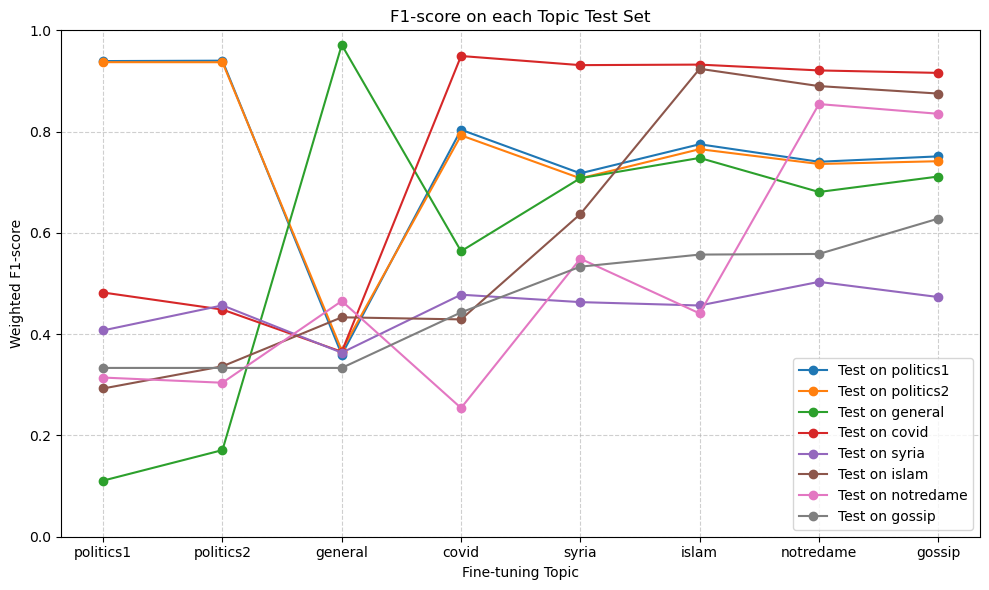

In [14]:
# ------------------
# Plot on each Topic
# ------------------

# extract topics
topics = list(results_topic.keys())
test_topics = list(next(iter(results_topic.values())).keys())

# make F1-score matrix
f1_matrix = np.array([[results_topic[train_topic][test_topic] for test_topic in test_topics] for train_topic in topics])

plt.figure(figsize=(10, 6))

# plot each test topic line
for i, test_topic in enumerate(test_topics):
    plt.plot(topics, f1_matrix[:, i], marker='o', label=f"Test on {test_topic}")

plt.title("F1-score on each Topic Test Set")
plt.xlabel("Fine-tuning Topic")
plt.ylabel("Weighted F1-score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

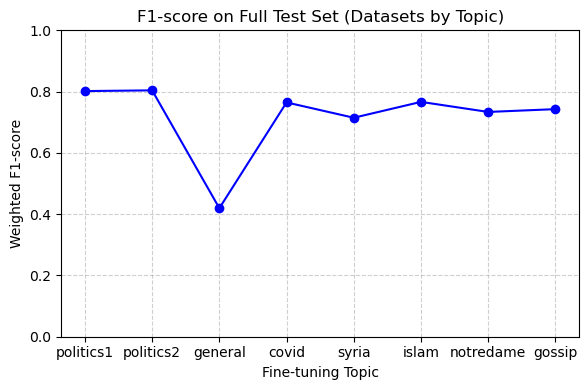

In [15]:
# ---------------------
# Plot on Full Test Set
# ---------------------

plt.figure(figsize=(6, 4))

# plot F1-score on full test set
plt.plot(topics, [results_full[topic] for topic in topics], marker='o', color='b')

plt.title("F1-score on Full Test Set (Datasets by Topic)")
plt.xlabel("Fine-tuning Topic")
plt.ylabel("Weighted F1-score")
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## VERSION 2: Dataset by Date

In [8]:
dataset_df = data_by_date()

print("\n--- DATASET SIZES BY DATE ---")
for date, df in dataset_df.items():
    print(f"Date: {date}, Number of samples: {len(df)}")

NameError: name 'data_by_date' is not defined

In [10]:
# --------------
# Split datasets
# --------------

datasets, tokenizer, encoder = prepare_data(dataset_df)

print("--- DATA SPLITS SIZES BY DATA ---")
for date, data_splits in datasets.items():
    print(f"Date: {date}")
    print(f"Train: {len(data_splits['train'][0])}, Val: {len(data_splits['val'][0])}, Test: {len(data_splits['test'][0])}")

--- DATA SPLITS SIZES BY DATA ---
Date: 2011-2013
Train: 33, Val: 11, Test: 11
Date: 2014
Train: 68, Val: 23, Test: 23
Date: 2015
Train: 50, Val: 17, Test: 17
Date: 2016
Train: 37810, Val: 12604, Test: 12604
Date: 2017
Train: 9994, Val: 3331, Test: 3332
Date: 2019
Train: 332, Val: 111, Test: 111
Date: 2020
Train: 6335, Val: 2112, Test: 2112


In [11]:
# ---------------------------
# Hyperparameter optimization
# ---------------------------

# merge all training and validation data across topics for optimization
X_train = np.concatenate([datasets[topic]['train'][0] for topic in datasets])
y_train = np.concatenate([datasets[topic]['train'][1] for topic in datasets])
X_val = np.concatenate([datasets[topic]['val'][0] for topic in datasets])
y_val = np.concatenate([datasets[topic]['val'][1] for topic in datasets])
# shuffle the combined training and validation data
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_val, y_val = shuffle(X_val, y_val, random_state=42)

embedding_matrix, num_words = load_word2vec(tokenizer)

# functools.partial to pass data to objective function
objective_with_data = partial(objectiveBiLSTM,
                              X_train=X_train,
                              X_val=X_val,
                              y_train=y_train,
                              y_val=y_val,
                              embedding_matrix=embedding_matrix,
                              num_words=num_words)

study = optuna.create_study(direction="maximize") # maximize F1-score
study.optimize(objective_with_data, n_trials=50) # 50 trials for demonstration; increase for better results

print("Best parameters:", study.best_params)


Loading pre-trained Word2Vec model (may take time)...


[I 2025-11-16 19:38:48,119] A new study created in memory with name: no-name-68f987e7-fdec-43ef-81aa-1d94dc537adb
I0000 00:00:1763318328.333319 3456524 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31134 MB memory:  -> device: 0, name: Tesla V100S-PCIE-32GB, pci bus id: 0000:af:00.0, compute capability: 7.0
2025-11-16 19:38:52.787998: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


570/570 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step


[I 2025-11-16 19:40:04,753] Trial 0 finished with value: 0.9505154639175257 and parameters: {'num_units': 32, 'dropout': 0.4, 'hidden_units': 64, 'learning_rate': 0.01}. Best is trial 0 with value: 0.9505154639175257.


570/570 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step


...

570/570 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step


[I 2025-11-16 23:54:36,150] Trial 48 finished with value: 0.9347807055939771 and parameters: {'num_units': 96, 'dropout': 0.8, 'hidden_units': 64, 'learning_rate': 0.001}. Best is trial 16 with value: 0.9602568552585907.


570/570 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step


[I 2025-11-16 23:56:56,499] Trial 49 finished with value: 0.949528936742934 and parameters: {'num_units': 96, 'dropout': 0.6, 'hidden_units': 8, 'learning_rate': 0.001}. Best is trial 16 with value: 0.9602568552585907.


Best parameters: {'num_units': 96, 'dropout': 0.8, 'hidden_units': 8, 'learning_rate': 0.001}


In [12]:
# ------------------------------
# Fine-tuning on Dataset by Date
# ------------------------------

best_params = study.best_params
best_model = build_model(
    embedding_matrix,
    num_words,
    embedding_dim=300,
    num_units=best_params["num_units"],
    dropout=best_params["dropout"],
    hidden_units=best_params["hidden_units"],
    learning_rate=best_params["learning_rate"]
)

results_date = {}
results_full = {}
X_full_test = np.concatenate([datasets[d]["test"][0] for d in datasets])
y_full_test = np.concatenate([datasets[d]["test"][1] for d in datasets])

# sequential training
for i, (date, data) in enumerate(datasets.items()):
    print(f"\n=== Phase {i+1}: Training/Fine-tuning on date: {date} ===")
    
    X_train, y_train = data["train"]
    X_val, y_val = data["val"]
    X_test, y_test = data["test"]

    # early stopping
    es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True, verbose=1)

    # fine-tune on train + val
    best_model.fit(
        np.concatenate([X_train, X_val]),
        np.concatenate([y_train, y_val]),
        epochs=50,
        batch_size=128,
        validation_data=(X_val, y_val),
        callbacks=[es],
        verbose=1
    )

    y_pred = best_model.predict(X_test)
    y_pred = (y_pred > 0.5).astype(int)
    print(f"Classification Report after date {date}:")
    print(classification_report(y_test, y_pred))
    print(f"Confusion Matrix after date {date}:")
    print(confusion_matrix(y_test, y_pred))
    print(f"\nWeighted F1-score after date {date}:", f1_score(y_test, y_pred, average="weighted"))

    # evaluation on all dates
    print("\n--- Evaluation on all dates ---")
    results_date[date] = {}
    for test_date, test_data in datasets.items(): # for each date
        X_te, y_te = test_data["test"]
        preds = best_model.predict(X_te)
        preds = (preds > 0.5).astype(int)
        f1 = f1_score(y_te, preds, average="weighted")
        results_date[date][test_date] = f1
        print(f"Evaluation on {test_date}: Weighted F1 = {f1:.4f}")
    
    # evaluation on full test set
    print("\n--- Evaluation on full test set ---")
    preds_full = best_model.predict(X_full_test)
    preds_full = (preds_full > 0.5).astype(int)
    f1_full = f1_score(y_full_test, preds_full, average="weighted")
    results_full[date] = f1_full
    print(f"Evaluation on full test set after date {date}: Weighted F1 = {f1_full:.4f}")


=== Phase 1: Training/Fine-tuning on date: 2011-2013 ===
Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4318 - loss: 0.6964 - val_accuracy: 0.4545 - val_loss: 0.6935
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step - accuracy: 0.5227 - loss: 0.6811 - val_accuracy: 0.6364 - val_loss: 0.6909
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 266ms/step - accuracy: 0.5000 - loss: 0.7226 - val_accuracy: 0.7273 - val_loss: 0.6890
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 271ms/step - accuracy: 0.6136 - loss: 0.6980 - val_accuracy: 0.6364 - val_loss: 0.6887
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.5000 - loss: 0.7090 - val_accuracy: 0.7273 - val_loss: 0.6882
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.4318 - loss: 0.7307 - val_accuracy: 0.7273 - val_loss: 0.6895
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.5455 - loss: 0.6938 - val_accuracy: 0.7273 - val_loss: 0.6901
Epoch 7: early stopping
Restoring model weights from the end of

In [13]:
# ---------------
# Results summary
# ---------------

print("\n=== Results Summary ===")
for date, res in results_date.items():
    print(f"\nResults after training on date {date}:")
    for test_date, f1 in res.items():
        print(f"  Test on date {test_date}: Weighted F1 = {f1:.4f}")

print("\nResults on full test set after each date training:")
for date, f1 in results_full.items():
    print(f"  After training on date {date}: Weighted F1 = {f1:.4f}")


=== Results Summary ===

Results after training on date 2011-2013:
  Test on date 2011-2013: Weighted F1 = 0.2338
  Test on date 2014: Weighted F1 = 0.5031
  Test on date 2015: Weighted F1 = 0.6446
  Test on date 2016: Weighted F1 = 0.4990
  Test on date 2017: Weighted F1 = 0.5020
  Test on date 2019: Weighted F1 = 0.4583
  Test on date 2020: Weighted F1 = 0.4947

Results after training on date 2014:
  Test on date 2011-2013: Weighted F1 = 0.5377
  Test on date 2014: Weighted F1 = 0.4722
  Test on date 2015: Weighted F1 = 0.5853
  Test on date 2016: Weighted F1 = 0.5578
  Test on date 2017: Weighted F1 = 0.6900
  Test on date 2019: Weighted F1 = 0.5001
  Test on date 2020: Weighted F1 = 0.3844

Results after training on date 2015:
  Test on date 2011-2013: Weighted F1 = 0.3850
  Test on date 2014: Weighted F1 = 0.3095
  Test on date 2015: Weighted F1 = 0.3665
  Test on date 2016: Weighted F1 = 0.2058
  Test on date 2017: Weighted F1 = 0.0000
  Test on date 2019: Weighted F1 = 0.2163
 

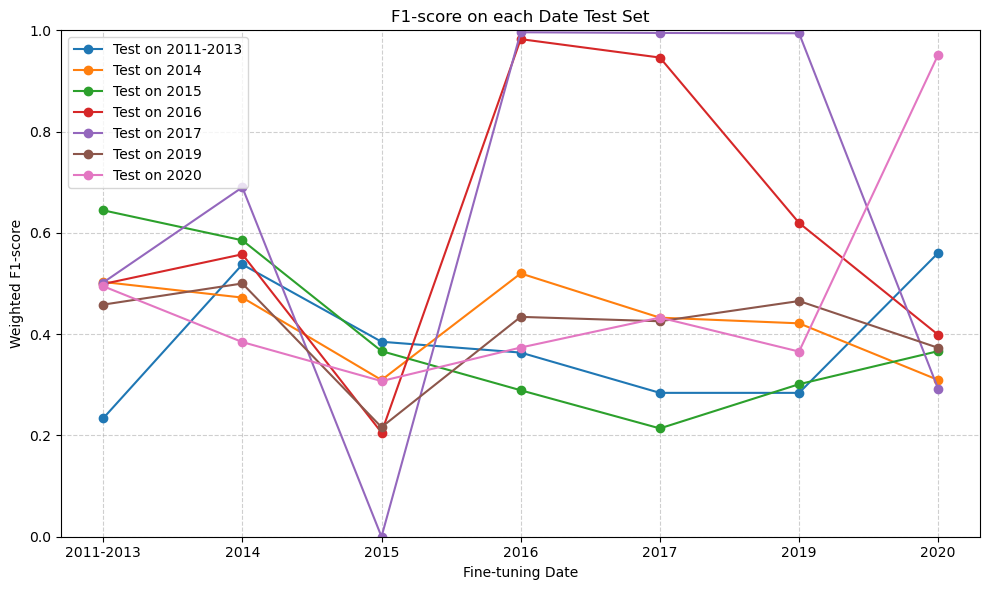

In [14]:
# ------------------
# Plot on each Date
# ------------------

# extract dates
dates = list(results_date.keys())
test_dates = list(next(iter(results_date.values())).keys())

# make F1-score matrix
f1_matrix = np.array([[results_date[train_date][test_date] for test_date in test_dates] for train_date in dates])
plt.figure(figsize=(10, 6))

# plot each test date line
for i, test_date in enumerate(test_dates):
    plt.plot(dates, f1_matrix[:, i], marker='o', label=f"Test on {test_date}")

plt.title("F1-score on each Date Test Set")
plt.xlabel("Fine-tuning Date")
plt.ylabel("Weighted F1-score")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

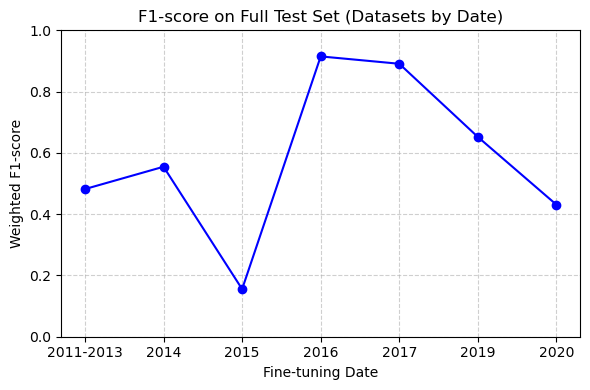

In [15]:
# ---------------------
# Plot on Full Test Set
# ---------------------

plt.figure(figsize=(6, 4))

# plot F1-score on full test set
plt.plot(dates, [results_full[date] for date in dates], marker='o', color='b')

plt.title("F1-score on Full Test Set (Datasets by Date)")
plt.xlabel("Fine-tuning Date")
plt.ylabel("Weighted F1-score")
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()